In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from scipy.signal import butter, filtfilt
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [2]:
dir = r'N:/Liu_Wanyi/forGithub'
data_dir = os.path.join(dir, 'data')

In [ ]:
# load data - all DRG units
drg_dict_file = os.path.join(data_dir,'drg_dict.pickle')
with open(drg_dict_file, 'rb') as handle:
    drg_units = pickle.load(handle)

In [4]:
units_latency_median = []
units_latency_median_FP = []
units_latency_median_HP = []
units_nspk_sync = []
units_nspk_opto = []
for i in range(9):
    units_latency_median.append(drg_units[i]['latency_median'])
    units_nspk_sync.append(drg_units[i]['nspk_sync'])
    units_nspk_opto.append(drg_units[i]['nspk_opto'])
    if i < 4:
        units_latency_median_HP.append(drg_units[i]['latency_median'])
    else:
        units_latency_median_FP.append(drg_units[i]['latency_median'])

In [5]:
units_pct_sync = np.array(units_nspk_sync)/300

units_nspk_opto = np.array(units_nspk_opto)
units_pct_opto_2Hz = units_nspk_opto[:,0] / (2*2*10)
units_pct_opto_5Hz = units_nspk_opto[:,1] / (5*2*10)
units_pct_opto_10Hz = units_nspk_opto[:,2] / (10*2*10)
units_pct_opto_20Hz = units_nspk_opto[:,3] / (20*2*10)
units_pct_opto_40Hz = units_nspk_opto[:,4] / (40*2*10)

mean_2Hz = np.mean(units_pct_opto_2Hz)
mean_5Hz = np.mean(units_pct_opto_5Hz)
mean_10Hz = np.mean(units_pct_opto_10Hz)
mean_20Hz = np.mean(units_pct_opto_20Hz)
mean_40Hz = np.mean(units_pct_opto_40Hz)
mean_sync = np.mean(units_pct_sync)

sd_2Hz = np.std(units_pct_opto_2Hz)
sd_5Hz = np.std(units_pct_opto_5Hz)
sd_10Hz = np.std(units_pct_opto_10Hz)
sd_20Hz = np.std(units_pct_opto_20Hz)
sd_40Hz = np.std(units_pct_opto_40Hz)
sd_sync = np.std(units_pct_sync)

C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_27780\2288251813.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['2 Hz','5 Hz','10 Hz','20 Hz','40 Hz','20Hz'])


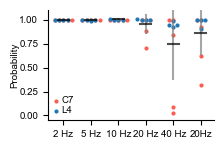

In [6]:
fig, ax = plt.subplots(figsize = (2.25,1.5))

markersize = 3

HP_idx = np.arange(0,4)
FP_idx = np.arange(4,9)

HP_color = '#1f77b4'
FP_color = "#f95e50"

dw = 0.2
mean_color = 'black'
sd_color = 'grey'

sns.swarmplot(ax=ax, x=1,y=units_pct_opto_2Hz[FP_idx], size = markersize, color=FP_color,label='C7')
sns.swarmplot(ax=ax, x=2,y=units_pct_opto_5Hz[FP_idx], size = markersize, color=FP_color)
sns.swarmplot(ax=ax, x=3,y=units_pct_opto_10Hz[FP_idx], size = markersize, color=FP_color)
sns.swarmplot(ax=ax, x=4,y=units_pct_opto_20Hz[FP_idx], size = markersize, color=FP_color)
sns.swarmplot(ax=ax, x=5,y=units_pct_opto_40Hz[FP_idx], size = markersize, color=FP_color)
sns.swarmplot(ax=ax, x=6,y=units_pct_sync[FP_idx], size = markersize, color=FP_color)

sns.swarmplot(ax=ax, x=1,y=units_pct_opto_2Hz[HP_idx], size = markersize, color=HP_color,label='L4')
sns.swarmplot(ax=ax, x=2,y=units_pct_opto_5Hz[HP_idx], size = markersize, color=HP_color)
sns.swarmplot(ax=ax, x=3,y=units_pct_opto_10Hz[HP_idx], size = markersize, color=HP_color)
sns.swarmplot(ax=ax, x=4,y=units_pct_opto_20Hz[HP_idx], size = markersize, color=HP_color)
sns.swarmplot(ax=ax, x=5,y=units_pct_opto_40Hz[HP_idx], size = markersize, color=HP_color)
sns.swarmplot(ax=ax, x=6,y=units_pct_sync[HP_idx], size = markersize, color=HP_color)

ax.plot([0-dw,0+dw],[mean_2Hz,mean_2Hz], color=mean_color,alpha=0.7,zorder=14)
ax.plot([1-dw,1+dw],[mean_5Hz,mean_5Hz], color=mean_color,alpha=0.7,zorder=14)
ax.plot([2-dw,2+dw],[mean_10Hz,mean_10Hz], color=mean_color,alpha=0.7,zorder=14)
ax.plot([3-dw,3+dw],[mean_20Hz,mean_20Hz], color=mean_color,alpha=0.7,zorder=14)
ax.plot([4-dw,4+dw],[mean_40Hz,mean_40Hz], color=mean_color,alpha=0.7,zorder=14)
ax.plot([5-dw,5+dw],[mean_sync,mean_sync], color=mean_color,alpha=0.7,zorder=14)

ax.plot([0,0],[mean_2Hz-sd_2Hz,mean_2Hz+sd_2Hz], color=sd_color,alpha=0.7,zorder=13)
ax.plot([1,1],[mean_5Hz-sd_5Hz,mean_5Hz+sd_5Hz], color=sd_color,alpha=0.7,zorder=13)
ax.plot([2,2],[mean_10Hz-sd_10Hz,mean_10Hz+sd_10Hz], color=sd_color,alpha=0.7,zorder=13)
ax.plot([3,3],[mean_20Hz-sd_20Hz,mean_20Hz+sd_20Hz], color=sd_color,alpha=0.7,zorder=13)
ax.plot([4,4],[mean_40Hz-sd_40Hz,mean_40Hz+sd_40Hz], color=sd_color,alpha=0.7,zorder=13)
ax.plot([5,5],[mean_sync-sd_sync,mean_sync+sd_sync], color=sd_color,alpha=0.7,zorder=13)

ax.set_ylim(-0.05,1.1)
ax.set_xticklabels(['2 Hz','5 Hz','10 Hz','20 Hz','40 Hz','20Hz'])

# ax.set_xticklabels(['2 Hz','5 Hz','10 Hz','20 Hz','40 Hz','20Hz\nIrregular'])
ax.set_xlabel('', labelpad=0)
ax.set_ylabel('Probability', labelpad=0.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(borderpad=0,      # Fractional whitespace inside the legend border
    labelspacing=0.1,   # Vertical space between entries
    handlelength=0.7,   # Length of the legend handles (lines/markers)
    handletextpad=0.2,  # Pad between handle and text
    columnspacing=0.5,  # Spacing between columns (if ncol > 1),
    loc = 'lower left',
    frameon=False)
plt.tight_layout()
# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\DRG_probability_add3.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()
